# Locked 2025 listed-options translation test

**Frozen evaluator/protocol checkpoint:** `59c02d73dc9134dcb157d4f2fbf06adf0d5db22c` (Phase A; 280 tests passed).

Forecasting results were already known before this trading experiment. Trading mechanics and the two diagnostic controls were frozen and pushed before inspecting 2025 option selections or trading P&L. This is a **locked translation test**, not a pristine new economic hypothesis. No post-result retuning, alternate strategy, selected offset or retry is allowed. See [trading protocol](../docs/trading_protocol.md).

The development-only RR25-spread M2 is fitted once, with coefficients frozen. A signal at EOD $t$ enters actual listed contracts at EOD $t+1$ and exits at EOD $t+5$, with a whole-basket $t+6$ fallback only. Quantities are fixed, fractional, and normalised to unit gross entry vega. All five original SPX-session offsets are reported.

P&L is in dollars per unit of entry gross vega **per decimal volatility**, not capital returns. Option bid/ask is included; the SPX hedge is frictionless, funding/financing is ignored, and there is no margin or integer-contract model. The pooled all-origin sample overlaps and is descriptive, not a constant-risk investable portfolio.

In [1]:
from pathlib import Path
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.forecasting import DEV_START, HOLDOUT_END
from src.time_series import build_daily_time_series
from src.trading_locked import (
    PNL_COLUMNS, run_locked_2025, trading_coverage, primary_statistics,
    offset_statistics, control_statistics, cumulative_pnl,
)

EVALUATOR_COMMIT = "59c02d73dc9134dcb157d4f2fbf06adf0d5db22c"
OUTPUT_DIR = ROOT / "data/processed/trading_locked_2025"
frozen_paths = [
    "src", "docs/trading_protocol.md", "docs/forecasts.md",
]
subprocess.run(
    ["git", "diff", "--exit-code", EVALUATOR_COMMIT, "--", *frozen_paths],
    cwd=ROOT, check=True, capture_output=True,
)
assert not (OUTPUT_DIR / "trading_locked_2025_run.json").exists(), (
    "Locked evaluation already attempted: do not rerun this notebook."
)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 180)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})

Matplotlib is building the font cache; this may take a moment.


## Single frozen run

Only the 2025 annual option file is streamed. Processed, QC-masked surface states and SPX closes supply the frozen signal and session calendar; realised forecast targets are not evaluator inputs. No 2025 outcome enters fitting, contract selection or trade eligibility. Large chains are not saved. Proprietary per-contract quotes and hedge/trade audits remain under gitignored `data/processed/trading_locked_2025/`.

An exclusive local manifest records this one attempt and prevents an automatic rerun. A technical exception stops the experiment; it is not a reason to modify and rerun the evaluator.

In [2]:
spx = pd.read_csv(
    ROOT / "data/raw/spx_security_prices.csv", parse_dates=["date"]
)
spx = spx.loc[spx.date <= HOLDOUT_END].copy()
metrics = pd.read_csv(
    ROOT / "data/processed/spx_skew_metrics_2023_2025.csv",
    parse_dates=["quote_date"],
)
metrics = metrics.loc[metrics.quote_date.between(DEV_START, HOLDOUT_END)].copy()
daily_surface = build_daily_time_series(metrics, spx)

result = run_locked_2025(
    ROOT / "data/raw/spx_option_prices_2025.csv",
    daily_surface, spx, EVALUATOR_COMMIT, OUTPUT_DIR, progress=True,
)
trades = result["trades"]
controls = result["controls"]

2025-01-31: 20/165 locked sessions processed


2025-03-03: 40/165 locked sessions processed


2025-03-31: 60/165 locked sessions processed


2025-04-29: 80/165 locked sessions processed


2025-05-28: 100/165 locked sessions processed


2025-06-26: 120/165 locked sessions processed


2025-07-25: 140/165 locked sessions processed


2025-08-22: 160/165 locked sessions processed


## Coverage first

Counts retain every confirmation session on the original SPX calendar. The last five origins cannot complete their scheduled horizon. Entries never depend on future quote availability. Skipped entries and unevaluable baskets stay in the audit; none is removed because of P&L.

In [3]:
display(trading_coverage(trades).to_frame())
display(
    trades.groupby(["status", "reason"], dropna=False).size()
    .rename("origins").to_frame()
)
display(pd.Series(result["signal_fit"], name="frozen development M2").to_frame())

,count
confirmation_sessions,165
full_exit_horizon,160
finite_nonzero_signal,162
entry_reached,157
entry_chain_available,157
expiry_pair_available,155
four_wings_available,149
evaluated,149
unevaluable,0
skipped,16


origins
status    reason                        
evaluated                            149
skipped   missing_25_delta_wing        6
          no_expiry_pair               2
          no_full_exit_horizon         5
          no_signal                    3

,frozen development M2
intercept,0.000654
slope,-0.001725
n_train,426
fit_end,2024-12-31 00:00:00
last_matured_origin,2024-12-23 00:00:00


## Primary bid/ask-adjusted delta-hedged result

All summaries below use evaluated trades only. The pooled sample is **overlapping and descriptive**. Midpoint option P&L uses the same identities, quantities and hedge path. Execution drag is executable option P&L minus midpoint option P&L and must be non-positive, apart from numerical tolerance. Drawdown starts from zero and cumulates trade results in actual-exit/origin order, in the same normalised units.

In [4]:
primary = primary_statistics(trades)
summary_fields = [
    "n", "total_option_pnl", "total_midpoint_option_pnl",
    "total_execution_drag", "total_hedge_pnl", "total_executable_total_pnl",
    "total_midpoint_total_pnl", "mean_executable_total_pnl",
    "median_executable_total_pnl", "std_executable_total_pnl",
    "positive_fraction_executable_total_pnl",
    "final_cumulative_executable_total_pnl", "max_drawdown_executable_total_pnl",
    "final_cumulative_midpoint_total_pnl", "max_drawdown_midpoint_total_pnl",
    "scope",
]
display(primary[summary_fields].to_frame("primary pooled result"))
component_stats = pd.DataFrame({
    column: {
        statistic: primary[f"{statistic}_{column}"]
        for statistic in ("total", "mean", "median", "std", "positive_fraction")
    }
    for column in PNL_COLUMNS
}).T
display(component_stats)

,primary pooled result
n,149
total_option_pnl,-0.475174
total_midpoint_option_pnl,-0.308779
total_execution_drag,-0.166395
total_hedge_pnl,0.279227
total_executable_total_pnl,-0.195946
total_midpoint_total_pnl,-0.029551
mean_executable_total_pnl,-0.001315
median_executable_total_pnl,-0.00066
std_executable_total_pnl,0.003636


,total,mean,median,std,positive_fraction
option_pnl,-0.475174,-0.003189,-0.001854,0.012729,0.348993
midpoint_option_pnl,-0.308779,-0.002072,-0.001239,0.011987,0.416107
execution_drag,-0.166395,-0.001117,-0.000800,0.001283,0.000000
hedge_pnl,0.279227,0.001874,0.001464,0.010400,0.597315
executable_total_pnl,-0.195946,-0.001315,-0.000660,0.003636,0.221477
midpoint_total_pnl,-0.029551,-0.000198,0.000106,0.002831,0.570470


## Five fixed, non-overlapping offsets

Offsets are the **original** forecast `session_index % 5`, never renumbered around missing signals or trades. Every offset is shown with equal prominence; none is selected. A fallback exit can coincide with the following same-offset entry at the same close.

,n,total_executable_total_pnl,mean_executable_total_pnl,median_executable_total_pnl,positive_fraction_executable_total_pnl,total_midpoint_total_pnl,total_execution_drag,total_hedge_pnl,max_drawdown_executable_total_pnl
offset,,,,,,,,,
0,29,-0.040466,-0.001395,-0.000637,0.206897,-0.007897,-0.032568,0.117547,0.040466
1,29,-0.047619,-0.001642,-0.000652,0.206897,-0.013331,-0.034288,0.118190,0.049243
2,31,-0.044529,-0.001436,-0.000688,0.258065,-0.006894,-0.037635,0.064161,0.044832
3,30,-0.036954,-0.001232,-0.000617,0.233333,-0.010637,-0.026316,-0.007479,0.036954
4,30,-0.026378,-0.000879,-0.000806,0.200000,0.009209,-0.035587,-0.013192,0.026378


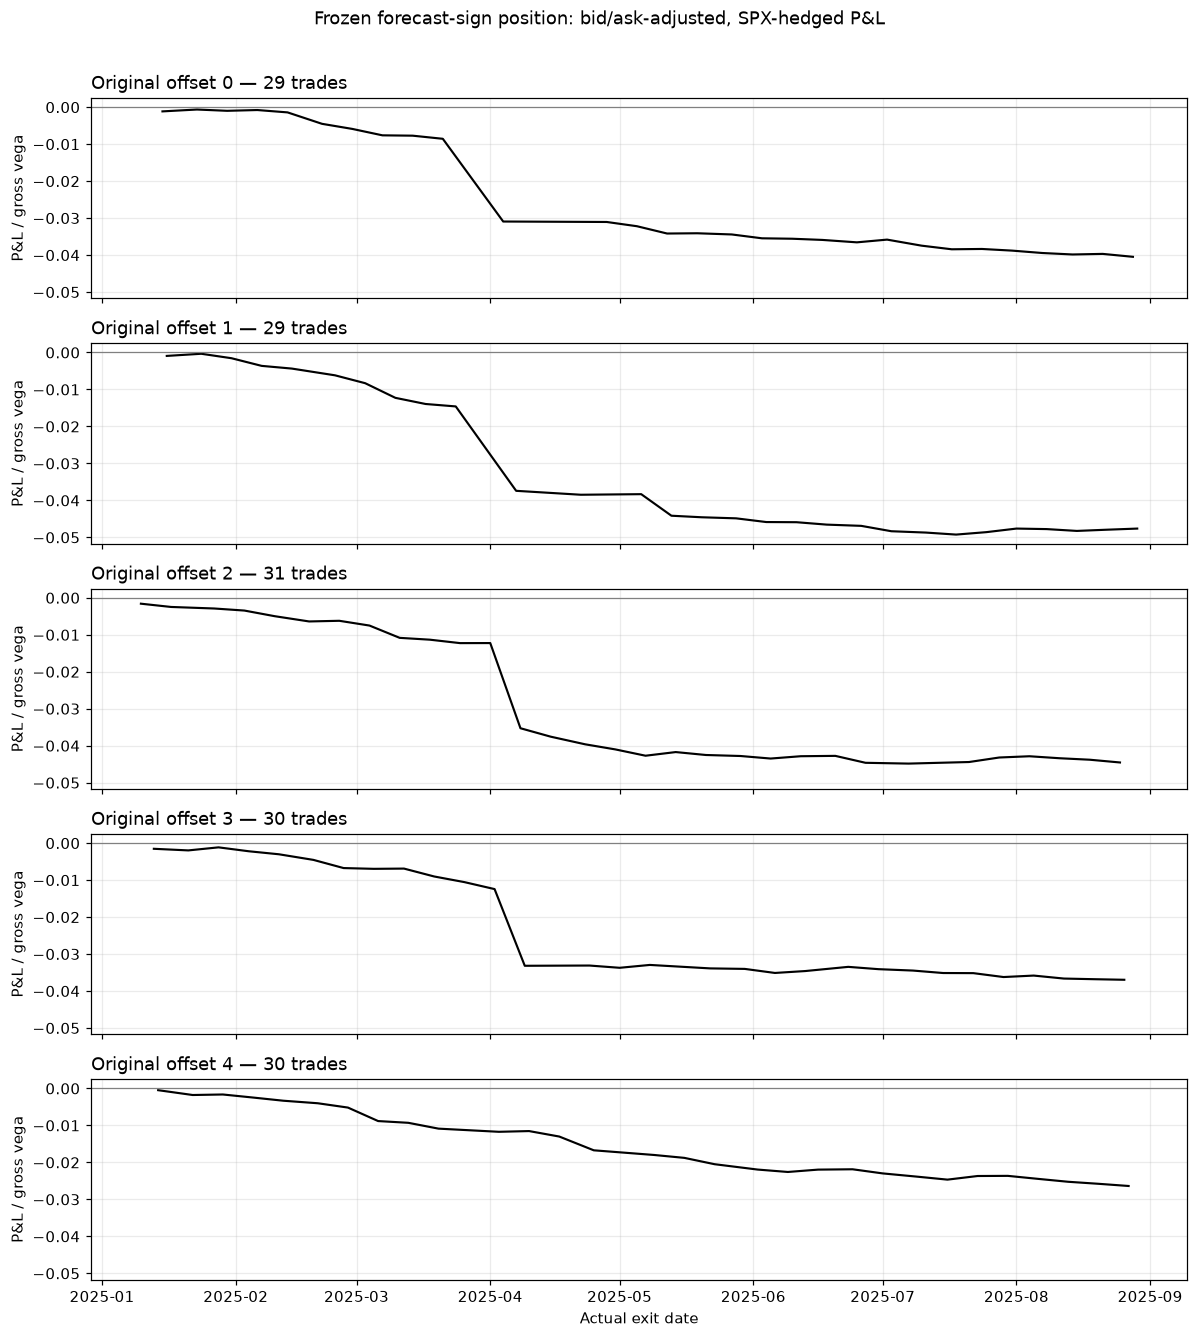

/var/folders/b0/929kwd6500bc9dk55s_br5l40000gn/T/ipykernel_62581/428646949.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [5]:
offsets = offset_statistics(trades)
display(offsets)

fig, axes = plt.subplots(5, 1, figsize=(11, 12), sharex=True, sharey=True)
for offset, ax in enumerate(axes):
    curve = cumulative_pnl(trades, offset=offset)
    ax.plot(curve.actual_exit, curve.cumulative_pnl, color="black", linewidth=1.4)
    ax.axhline(0, color="grey", linewidth=.8)
    ax.set_title(f"Original offset {offset} — {int(offsets.loc[offset, 'n'])} trades", loc="left")
    ax.set_ylabel("P&L / gross vega")
axes[-1].set_xlabel("Actual exit date")
fig.suptitle("Frozen forecast-sign position: bid/ask-adjusted, SPX-hedged P&L", y=1.01)
fig.tight_layout()
plt.show()

## Midpoint versus executable decomposition

$$\text{midpoint option P\&L}+\text{execution drag}=\text{executable option P\&L}$$
$$\text{executable option P\&L}+\text{hedge P\&L}=\text{executable total P\&L}.$$

Pooled cumulative curves below overlap and are descriptive. They are neither capital returns nor independent-trade evidence.

,pooled total
Midpoint option P&L,-0.308779
Execution drag,-0.166395
Executable option P&L,-0.475174
SPX hedge P&L,0.279227
Executable total P&L,-0.195946
Midpoint total P&L,-0.029551


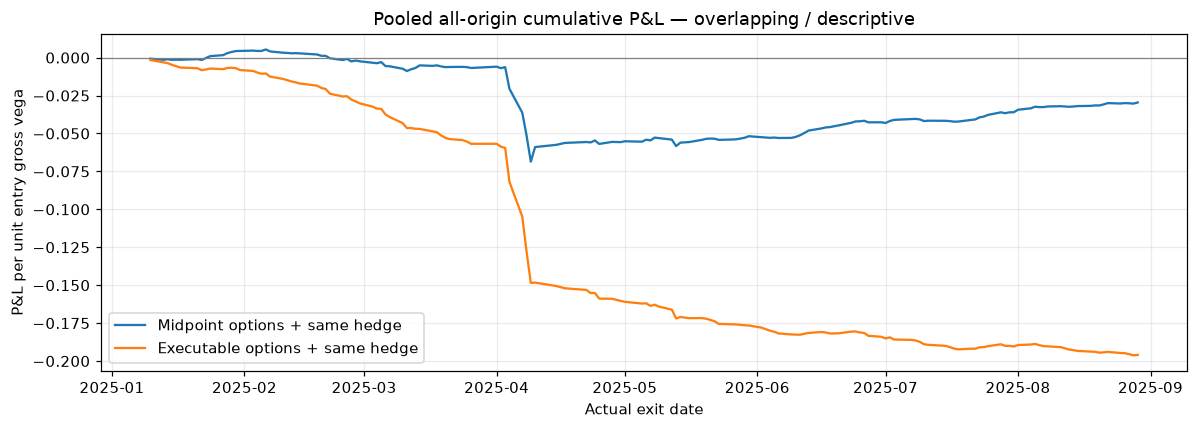

/var/folders/b0/929kwd6500bc9dk55s_br5l40000gn/T/ipykernel_62581/3264321205.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
decomposition = pd.Series({
    "Midpoint option P&L": primary["total_midpoint_option_pnl"],
    "Execution drag": primary["total_execution_drag"],
    "Executable option P&L": primary["total_option_pnl"],
    "SPX hedge P&L": primary["total_hedge_pnl"],
    "Executable total P&L": primary["total_executable_total_pnl"],
    "Midpoint total P&L": primary["total_midpoint_total_pnl"],
}, name="pooled total")
display(decomposition.to_frame())

fig, ax = plt.subplots(figsize=(11, 4))
for column, label in [
    ("midpoint_total_pnl", "Midpoint options + same hedge"),
    ("executable_total_pnl", "Executable options + same hedge"),
]:
    curve = cumulative_pnl(trades, column)
    ax.plot(curve.actual_exit, curve.cumulative_pnl, label=label)
ax.axhline(0, color="grey", linewidth=.8)
ax.set(
    title="Pooled all-origin cumulative P&L — overlapping / descriptive",
    xlabel="Actual exit date", ylabel="P&L per unit entry gross vega",
)
ax.legend()
fig.tight_layout()
plt.show()

## Predeclared diagnostic controls

Reverse-sign and constant-positive-direction positions use **exactly the primary evaluated origins and selected contracts**. Their own delta hedges are recalculated from their quantities. Neither control can replace the frozen strategy, regardless of these results. There are no additional controls or parameter comparisons.

In [7]:
control_summary = control_statistics(trades, controls)
display(control_summary)

,n,total_executable_total_pnl,total_midpoint_total_pnl,total_execution_drag,total_hedge_pnl,mean_executable_total_pnl,positive_fraction
variant,,,,,,,
primary,149,-0.195946,-0.029551,-0.166395,0.279227,-0.001315,0.221477
reversed_sign,149,-0.136844,0.029551,-0.166395,-0.279227,-0.000918,0.120805
constant_positive,149,-0.087431,0.078964,-0.166395,0.097172,-0.000587,0.268456


## Factual interpretation and limitations

The following reports the frozen result without selecting a different strategy. Negative executable totals must not be rescued by changing timing, costs, signal thresholds, tenors or direction. Positive midpoint P&L alone would not establish executable trading profitability.

The SPX hedge has no execution costs, fractional contracts are theoretical, financing and margin are omitted, and this short sample ends in August 2025. Forecasting evidence was known before the hypothesis was translated into trades. No annualised Sharpe, capital return, significance or production-readiness claim is made.

In [8]:
total = float(primary["total_executable_total_pnl"])
midpoint = float(primary["total_midpoint_total_pnl"])
drag = float(primary["total_execution_drag"])
hedge = float(primary["total_hedge_pnl"])
positive_offsets = int(offsets.total_executable_total_pnl.gt(0).sum())
reverse = float(control_summary.loc["reversed_sign", "total_executable_total_pnl"])
constant = float(control_summary.loc["constant_positive", "total_executable_total_pnl"])
print(f"Executable delta-hedged total: {total:.6f} ({'positive' if total > 0 else 'non-positive'}).")
print(f"Midpoint option total: {float(primary['total_midpoint_option_pnl']):.6f}.")
print(f"Midpoint delta-hedged total: {midpoint:.6f}; execution drag: {drag:.6f}.")
print(f"SPX hedge contribution: {hedge:.6f}; executable option component: {float(primary['total_option_pnl']):.6f}.")
print(f"Offsets with positive executable total: {positive_offsets}/5; no offset selected.")
print(f"Primary exceeds reversed-sign control: {total > reverse}.")
print(f"Primary exceeds constant-positive control: {total > constant}.")
if total > 0:
    print("The frozen backtest has positive bid/ask-adjusted delta-hedged P&L; the proxy/capital limitations still apply.")
elif midpoint > 0:
    print("Midpoint delta-hedged P&L is positive, but option bid/ask removes it in this locked translation test.")
else:
    print("The forecast does not translate cleanly into positive listed-option delta-hedged P&L in this locked sample, even at midpoint.")
print("No post-result retuning or alternate trading experiment was performed.")
print(f"Immutable evaluator checkpoint: {EVALUATOR_COMMIT}")
print("Quote-level trade/leg/hedge audits and the one-attempt manifest are gitignored.")

Executable delta-hedged total: -0.195946 (non-positive).
Midpoint option total: -0.308779.
Midpoint delta-hedged total: -0.029551; execution drag: -0.166395.
SPX hedge contribution: 0.279227; executable option component: -0.475174.
Offsets with positive executable total: 0/5; no offset selected.
Primary exceeds reversed-sign control: False.
Primary exceeds constant-positive control: False.
The forecast does not translate cleanly into positive listed-option delta-hedged P&L in this locked sample, even at midpoint.
No post-result retuning or alternate trading experiment was performed.
Immutable evaluator checkpoint: 59c02d73dc9134dcb157d4f2fbf06adf0d5db22c
Quote-level trade/leg/hedge audits and the one-attempt manifest are gitignored.
